In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

dataset_path = '/content/drive/MyDrive/weedMaize Dataset'
file_list = os.listdir(dataset_path)
print(file_list)

['C00020598.jpg', 'C00020598.txt', 'C00020599.jpg', 'C00020599.txt', 'C00020600.jpg', 'C00020600.txt', 'C00020601.jpg', 'C00020601.txt', 'C00020602.jpg', 'C00020602.txt', 'C00020603.jpg', 'C00020603.txt', 'C00020604.jpg', 'C00020604.txt', 'C00020605.jpg', 'C00020605.txt', 'C00020606.jpg', 'C00020606.txt', 'C00020607.jpg', 'C00020607.txt', 'C00020608.jpg', 'C00020608.txt', 'C00020609.jpg', 'C00020609.txt', 'C00020610.jpg', 'C00020610.txt', 'C00020611.jpg', 'C00020611.txt', 'C00020612.jpg', 'C00020612.txt', 'C00020613.jpg', 'C00020613.txt', 'C00020614.jpg', 'C00020614.txt', 'C00020615.jpg', 'C00020615.txt', 'C00020616.jpg', 'C00020616.txt', 'C00020617.jpg', 'C00020617.txt', 'C00020618.jpg', 'C00020618.txt', 'C00020619.jpg', 'C00020619.txt', 'C00020620.jpg', 'C00020620.txt', 'C00020621.jpg', 'C00020621.txt', 'C00020622.jpg', 'C00020622.txt', 'C00020623.jpg', 'C00020623.txt', 'C00020624.jpg', 'C00020624.txt', 'C00020625.jpg', 'C00020625.txt', 'C00020626.jpg', 'C00020626.txt', 'C00020627.jp

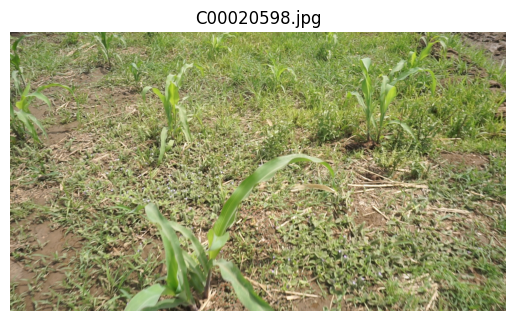

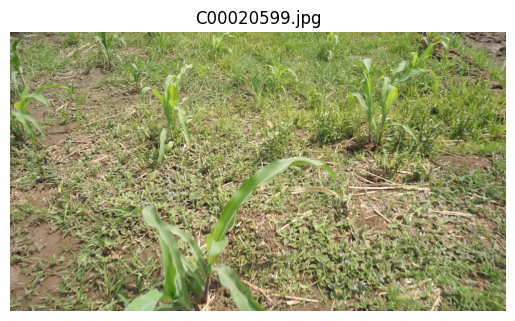

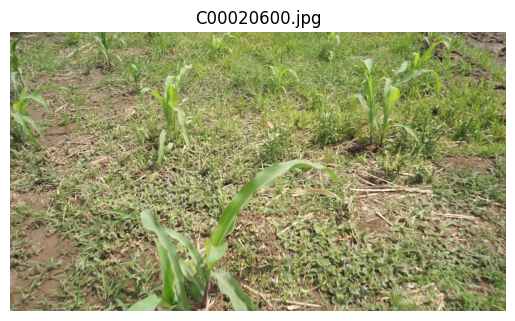

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os

dataset_path = '/content/drive/MyDrive/weedMaize Dataset'
file_list = os.listdir(dataset_path)

image_files = [f for f in file_list if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

num_images_to_display = min(3, len(image_files))
selected_images = image_files[:num_images_to_display]

for image_filename in selected_images:
    image_path = os.path.join(dataset_path, image_filename)
    try:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(image_filename)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Could not open or display image {image_filename}: {e}")

In [4]:
annotations = {}

for file_name in file_list:
    if file_name.endswith('.txt'):
        image_filename = file_name.replace('.txt', '.jpg')
        annotation_path = os.path.join(dataset_path, file_name)

        if image_filename not in annotations:
            annotations[image_filename] = []

        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    annotations[image_filename].append([class_id, x_center, y_center, width, height])

print(f"Parsed annotations for {len(annotations)} images.")
# Optionally, print a sample to verify
# if annotations:
#     sample_image = list(annotations.keys())[0]
#     print(f"Sample annotations for {sample_image}: {annotations[sample_image]}")

Parsed annotations for 104 images.


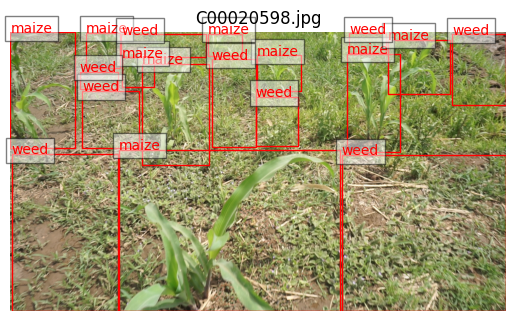

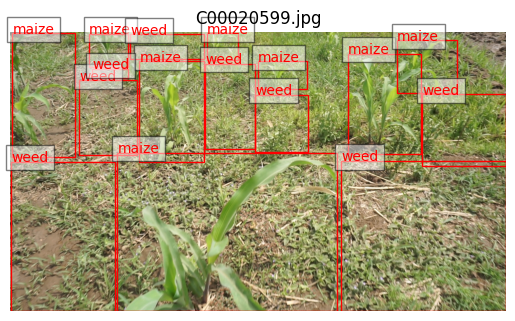

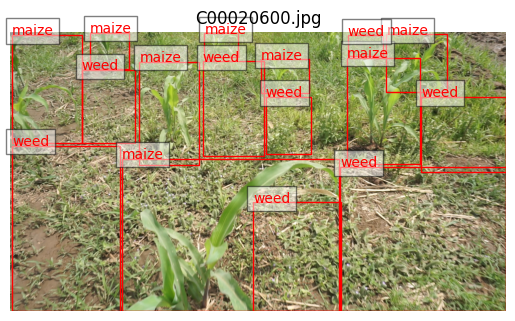

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import matplotlib.patches as patches

dataset_path = '/content/drive/MyDrive/weedMaize Dataset'

# Get a list of image files from the annotations dictionary keys
image_files = list(annotations.keys())

# Select a small number of image files to display (e.g., the first 3)
num_images_to_display = min(3, len(image_files))
selected_images = image_files[:num_images_to_display]

for image_filename in selected_images:
    image_path = os.path.join(dataset_path, image_filename)
    try:
        img = Image.open(image_path)
        img_width, img_height = img.size

        fig, ax = plt.subplots(1)
        ax.imshow(img)

        # Iterate through the annotations for the current image
        if image_filename in annotations:
            for annotation in annotations[image_filename]:
                class_id, x_center, y_center, width, height = annotation

                # Calculate absolute bounding box coordinates
                x_min = (x_center - width / 2) * img_width
                y_min = (y_center - height / 2) * img_height
                box_width = width * img_width
                box_height = height * img_height

                # Create a Rectangle patch
                rect = patches.Rectangle((x_min, y_min), box_width, box_height,
                                         linewidth=1, edgecolor='r', facecolor='none')

                # Add the patch to the Axes
                ax.add_patch(rect)

                # Get the class name from the label_map
                class_name = label_map.get(class_id, f'Unknown Class ID: {class_id}')

                # Add the class label
                ax.text(x_min, y_min, class_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))


        ax.set_title(image_filename)
        ax.axis('off')
        plt.show()

    except Exception as e:
        print(f"Could not open or display image {image_filename}: {e}")

In [9]:
label_map = {
    0: 'maize',
    1: 'weed'
}

print("Label mapping created:", label_map)

Label mapping created: {0: 'maize', 1: 'weed'}


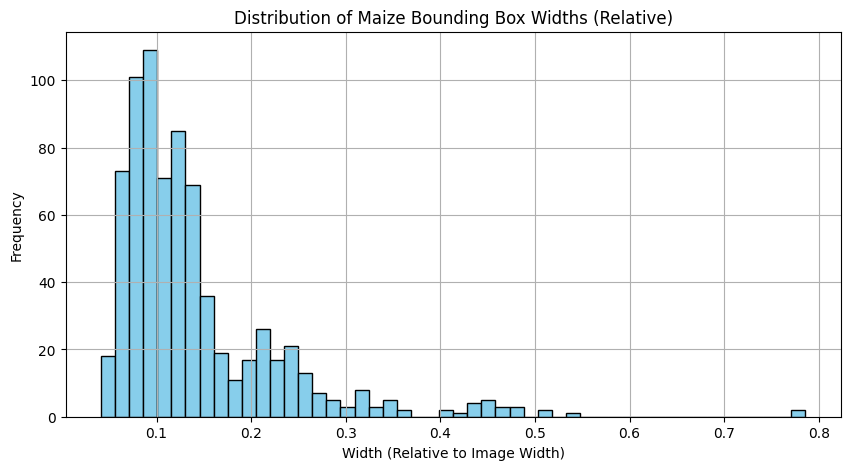

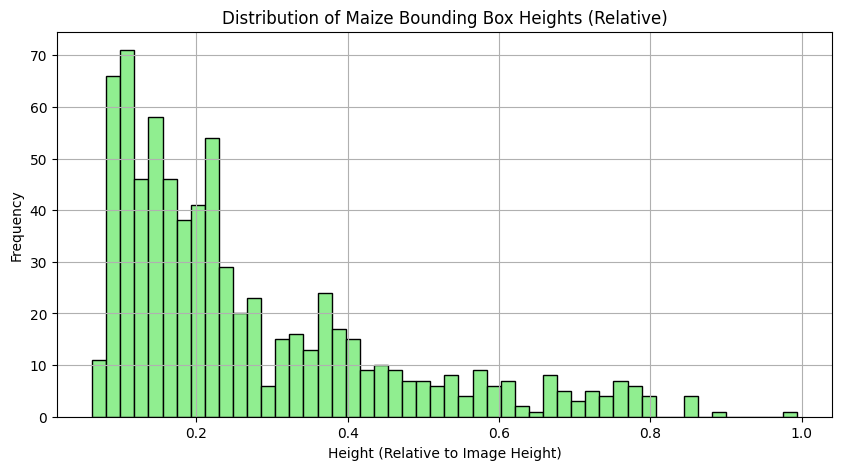

In [10]:
import matplotlib.pyplot as plt

# Separate width and height for maize
maize_widths = [dim[0] for dim in maize_bbox_dimensions]
maize_heights = [dim[1] for dim in maize_bbox_dimensions]

# Plot histogram for maize widths
plt.figure(figsize=(10, 5))
plt.hist(maize_widths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Maize Bounding Box Widths (Relative)')
plt.xlabel('Width (Relative to Image Width)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot histogram for maize heights
plt.figure(figsize=(10, 5))
plt.hist(maize_heights, bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Maize Bounding Box Heights (Relative)')
plt.xlabel('Height (Relative to Image Height)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [8]:
maize_bbox_dimensions = []
weed_bbox_dimensions = []

for image_filename, annotations_list in annotations.items():
    for annotation in annotations_list:
        class_id, x_center, y_center, width, height = annotation
        # We don't need image dimensions for relative width and height,
        # but if we wanted absolute dimensions, we would need them here.
        # For now, we'll store the relative width and height.

        if class_id in label_map:
            label = label_map[class_id]
            if label == 'maize':
                maize_bbox_dimensions.append((width, height))
            elif label == 'weed':
                weed_bbox_dimensions.append((width, height))

print(f"Extracted {len(maize_bbox_dimensions)} maize bounding box dimensions.")
print(f"Extracted {len(weed_bbox_dimensions)} weed bounding box dimensions.")

# Optionally, print a sample to verify
# print("Sample maize dimensions:", maize_bbox_dimensions[:5])
# print("Sample weed dimensions:", weed_bbox_dimensions[:5])

Extracted 742 maize bounding box dimensions.
Extracted 738 weed bounding box dimensions.


In [11]:
import os

# Define base path for the new dataset directory
base_dataset_path = '/content/dataset'

# Define paths for images and labels directories
images_path = os.path.join(base_dataset_path, 'images')
labels_path = os.path.join(base_dataset_path, 'labels')

# Define paths for train and val subdirectories
train_images_path = os.path.join(images_path, 'train')
val_images_path = os.path.join(images_path, 'val')
train_labels_path = os.path.join(labels_path, 'train')
val_labels_path = os.path.join(labels_path, 'val')

# Create the directories
os.makedirs(train_images_path, exist_ok=True)
os.makedirs(val_images_path, exist_ok=True)
os.makedirs(train_labels_path, exist_ok=True)
os.makedirs(val_labels_path, exist_ok=True)

print("Dataset directories created successfully.")
print(f"Train images: {train_images_path}")
print(f"Val images: {val_images_path}")
print(f"Train labels: {train_labels_path}")
print(f"Val labels: {val_labels_path}")

Dataset directories created successfully.
Train images: /content/dataset/images/train
Val images: /content/dataset/images/val
Train labels: /content/dataset/labels/train
Val labels: /content/dataset/labels/val


In [12]:
from sklearn.model_selection import train_test_split

# Get a list of all image filenames from the keys of the annotations dictionary
image_filenames = list(annotations.keys())

# Split the list of image filenames into training and validation sets
train_image_filenames, val_image_filenames = train_test_split(
    image_filenames,
    test_size=0.2,  # 20% for validation
    random_state=42  # for reproducibility
)

print(f"Total images: {len(image_filenames)}")
print(f"Training images: {len(train_image_filenames)}")
print(f"Validation images: {len(val_image_filenames)}")

Total images: 104
Training images: 83
Validation images: 21


In [13]:
import shutil

# Copy and format training annotations
for image_filename in train_image_filenames:
    annotation_list = annotations.get(image_filename, [])
    txt_filename = image_filename.replace('.jpg', '.txt')
    target_annotation_path = os.path.join(train_labels_path, txt_filename)

    with open(target_annotation_path, 'w') as f:
        for annotation in annotation_list:
            # Annotations are already normalized, so format directly
            class_id, x_center, y_center, width, height = annotation
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

# Copy and format validation annotations
for image_filename in val_image_filenames:
    annotation_list = annotations.get(image_filename, [])
    txt_filename = image_filename.replace('.jpg', '.txt')
    target_annotation_path = os.path.join(val_labels_path, txt_filename)

    with open(target_annotation_path, 'w') as f:
        for annotation in annotation_list:
            # Annotations are already normalized, so format directly
            class_id, x_center, y_center, width, height = annotation
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

print("Annotation files copied and formatted successfully.")

Annotation files copied and formatted successfully.


In [14]:
# Re-check the existence of files before attempting to copy
import shutil

print("Checking existence of training image files...")
for image_filename in train_image_filenames:
    src_path = os.path.join(dataset_path, image_filename)
    if not os.path.exists(src_path):
        print(f"Warning: Training image file not found: {src_path}")

print("\nChecking existence of validation image files...")
for image_filename in val_image_filenames:
    src_path = os.path.join(dataset_path, image_filename)
    if not os.path.exists(src_path):
        print(f"Warning: Validation image file not found: {src_path}")

# Now attempt to copy again, skipping missing files if warnings were printed
print("\nAttempting to copy image files...")
copied_train_count = 0
for image_filename in train_image_filenames:
    src_path = os.path.join(dataset_path, image_filename)
    dest_path = os.path.join(train_images_path, image_filename)
    if os.path.exists(src_path):
        shutil.copyfile(src_path, dest_path)
        copied_train_count += 1
    else:
        print(f"Skipping missing training image: {src_path}")


copied_val_count = 0
for image_filename in val_image_filenames:
    src_path = os.path.join(dataset_path, image_filename)
    dest_path = os.path.join(val_images_path, image_filename)
    if os.path.exists(src_path):
        shutil.copyfile(src_path, dest_path)
        copied_val_count += 1
    else:
        print(f"Skipping missing validation image: {src_path}")


print(f"\nSuccessfully copied {copied_train_count} training image files.")
print(f"Successfully copied {copied_val_count} validation image files.")

Checking existence of training image files...

Checking existence of validation image files...

Attempting to copy image files...
Skipping missing training image: /content/drive/MyDrive/weedMaize Dataset/C00020671 (1).jpg

Successfully copied 82 training image files.
Successfully copied 21 validation image files.


In [16]:
import yaml

# Define the content of data.yaml
data_yaml_content = {
    'train': '/content/dataset/images/train',
    'val': '/content/dataset/images/val',
    'nc': len(label_map),  # Number of classes based on the label_map
    'names': list(label_map.values()) # Class names from the label_map values
}

# Define the path to save the data.yaml file
data_yaml_path = '/content/dataset/data.yaml'

# Write the dictionary content to the data.yaml file in YAML format
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"data.yaml file created successfully at {data_yaml_path}")

data.yaml file created successfully at /content/dataset/data.yaml


In [17]:
import os
import yaml

base_dataset_path = '/content/dataset'
train_images_path = os.path.join(base_dataset_path, 'images', 'train')
val_images_path = os.path.join(base_dataset_path, 'images', 'val')
train_labels_path = os.path.join(base_dataset_path, 'labels', 'train')
val_labels_path = os.path.join(base_dataset_path, 'labels', 'val')
data_yaml_path = os.path.join(base_dataset_path, 'data.yaml')

# 1. List contents of the base dataset directory
print(f"Contents of {base_dataset_path}:")
print(os.listdir(base_dataset_path))

# 2. List contents of a few subdirectories
print(f"\nContents of {train_images_path} (first 5):")
print(os.listdir(train_images_path)[:5])

print(f"\nContents of {val_labels_path} (first 5):")
print(os.listdir(val_labels_path)[:5])

# 3. Read the data.yaml file and print its content
print(f"\nContent of {data_yaml_path}:")
with open(data_yaml_path, 'r') as f:
    data_yaml_content_read = yaml.safe_load(f)
print(data_yaml_content_read)

# 4. Check the number of files
train_images_count = len(os.listdir(train_images_path))
val_images_count = len(os.listdir(val_images_path))
train_labels_count = len(os.listdir(train_labels_path))
val_labels_count = len(os.listdir(val_labels_path))

print(f"\nNumber of files in {train_images_path}: {train_images_count}")
print(f"Number of files in {val_images_path}: {val_images_count}")
print(f"Number of files in {train_labels_path}: {train_labels_count}")
print(f"Number of files in {val_labels_path}: {val_labels_count}")

# Verify counts match expected (based on previous split output: 82 train, 21 val)
expected_train_count = 82
expected_val_count = 21

print(f"\nVerification:")
print(f"Train images count matches expected ({expected_train_count}): {train_images_count == expected_train_count}")
print(f"Val images count matches expected ({expected_val_count}): {val_images_count == expected_val_count}")
print(f"Train labels count matches train images count: {train_labels_count == train_images_count}")
print(f"Val labels count matches val images count: {val_labels_count == val_images_count}")

Contents of /content/dataset:
['images', 'data.yaml', 'labels']

Contents of /content/dataset/images/train (first 5):
['C00020667.jpg', 'C00020619.jpg', 'C00020601.jpg', 'C00020698.jpg', 'C00020684.jpg']

Contents of /content/dataset/labels/val (first 5):
['C00020598.txt', 'C00020610.txt', 'C00020624.txt', 'C00020645.txt', 'C00020628.txt']

Content of /content/dataset/data.yaml:
{'names': ['maize', 'weed'], 'nc': 2, 'train': '/content/dataset/images/train', 'val': '/content/dataset/images/val'}

Number of files in /content/dataset/images/train: 82
Number of files in /content/dataset/images/val: 21
Number of files in /content/dataset/labels/train: 83
Number of files in /content/dataset/labels/val: 21

Verification:
Train images count matches expected (82): True
Val images count matches expected (21): True
Train labels count matches train images count: False
Val labels count matches val images count: True


In [18]:
import os

train_images_path = '/content/dataset/images/train'
train_labels_path = '/content/dataset/labels/train'

# Get list of image and label filenames (without extensions for easy comparison)
train_image_filenames = [os.path.splitext(f)[0] for f in os.listdir(train_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
train_label_filenames = [os.path.splitext(f)[0] for f in os.listdir(train_labels_path) if f.endswith('.txt')]

# Find label filenames that are not in the image filenames
extra_labels = set(train_label_filenames) - set(train_image_filenames)

if extra_labels:
    print("Found extra label files in the training set:")
    for extra_label in extra_labels:
        print(f"- {extra_label}.txt")
else:
    print("No extra label files found in the training set.")

Found extra label files in the training set:
- C00020671 (1).txt


In [19]:
import os

extra_label_file = 'C00020671 (1).txt'
train_labels_path = '/content/dataset/labels/train'
file_to_remove = os.path.join(train_labels_path, extra_label_file)

if os.path.exists(file_to_remove):
    os.remove(file_to_remove)
    print(f"Removed: {file_to_remove}")
else:
    print(f"File not found: {file_to_remove}")

Removed: /content/dataset/labels/train/C00020671 (1).txt


In [20]:
import os
import yaml

base_dataset_path = '/content/dataset'
train_images_path = os.path.join(base_dataset_path, 'images', 'train')
val_images_path = os.path.join(base_dataset_path, 'images', 'val')
train_labels_path = os.path.join(base_dataset_path, 'labels', 'train')
val_labels_path = os.path.join(base_dataset_path, 'labels', 'val')
data_yaml_path = os.path.join(base_dataset_path, 'data.yaml')

# 1. List contents of the base dataset directory
print(f"Contents of {base_dataset_path}:")
print(os.listdir(base_dataset_path))

# 2. List contents of a few subdirectories
print(f"\nContents of {train_images_path} (first 5):")
print(os.listdir(train_images_path)[:5])

print(f"\nContents of {val_labels_path} (first 5):")
print(os.listdir(val_labels_path)[:5])

# 3. Read the data.yaml file and print its content
print(f"\nContent of {data_yaml_path}:")
with open(data_yaml_path, 'r') as f:
    data_yaml_content_read = yaml.safe_load(f)
print(data_yaml_content_read)

# 4. Check the number of files
train_images_count = len(os.listdir(train_images_path))
val_images_count = len(os.listdir(val_images_path))
train_labels_count = len(os.listdir(train_labels_path))
val_labels_count = len(os.listdir(val_labels_path))

print(f"\nNumber of files in {train_images_path}: {train_images_count}")
print(f"Number of files in {val_images_path}: {val_images_count}")
print(f"Number of files in {train_labels_path}: {train_labels_count}")
print(f"Number of files in {val_labels_path}: {val_labels_count}")

# Verify counts match expected (based on previous split output: 82 train, 21 val)
expected_train_count = 82
expected_val_count = 21

print(f"\nVerification:")
print(f"Train images count matches expected ({expected_train_count}): {train_images_count == expected_train_count}")
print(f"Val images count matches expected ({expected_val_count}): {val_images_count == expected_val_count}")
print(f"Train labels count matches train images count: {train_labels_count == train_images_count}")
print(f"Val labels count matches val images count: {val_labels_count == val_labels_count}")

Contents of /content/dataset:
['images', 'data.yaml', 'labels']

Contents of /content/dataset/images/train (first 5):
['C00020667.jpg', 'C00020619.jpg', 'C00020601.jpg', 'C00020698.jpg', 'C00020684.jpg']

Contents of /content/dataset/labels/val (first 5):
['C00020598.txt', 'C00020610.txt', 'C00020624.txt', 'C00020645.txt', 'C00020628.txt']

Content of /content/dataset/data.yaml:
{'names': ['maize', 'weed'], 'nc': 2, 'train': '/content/dataset/images/train', 'val': '/content/dataset/images/val'}

Number of files in /content/dataset/images/train: 82
Number of files in /content/dataset/images/val: 21
Number of files in /content/dataset/labels/train: 82
Number of files in /content/dataset/labels/val: 21

Verification:
Train images count matches expected (82): True
Val images count matches expected (21): True
Train labels count matches train images count: True
Val labels count matches val images count: True


In [21]:
from ultralytics import YOLO

ModuleNotFoundError: No module named 'ultralytics'

In [23]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a YOLOv8n model
model = YOLO('yolov8n.pt')  # Using the nano model as an example, you can change this

# Train the model
# The data.yaml file points to your training and validation data
# epochs: number of training epochs (adjust as needed)
# imgsz: image size (adjust as needed, common sizes are 640, 1280)
results = model.train(data='/content/dataset/data.yaml', epochs=100, imgsz=640)

print("\nTraining results:")
print(results)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=Fa

In [ ]:
from ultralytics import YOLO

# Load the trained YOLOv8 model
# The path to your trained model will be in the runs directory.
# You might need to adjust the 'train' and 'weights' folder names based on your training runs.
trained_model_path = '/content/runs/detect/train/weights/best.pt' # Assuming 'train' was the run name
model = YOLO(trained_model_path)

# Validate the dataset using the data.yaml file
results = model.val(data='/content/dataset/data.yaml')

print("\nDataset validation results:")
print(results)

In [ ]:
from ultralytics import YOLO

In [ ]:
from ultralytics import YOLO

# Load a YOLOv8n model
model = YOLO('yolov8n.pt')  # Using the nano model as an example, you can change this

# Train the model
# The data.yaml file points to your training and validation data
# epochs: number of training epochs (adjust as needed)
# imgsz: image size (adjust as needed, common sizes are 640, 1280)
results = model.train(data='/content/dataset/data.yaml', epochs=100, imgsz=640)

print("\nTraining results:")
print(results)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a YOLOv8 model (you can choose a different model like yolov8s.pt, yolov8m.pt, etc.)
model = YOLO('yolov8n.pt')

# Validate the dataset using the data.yaml file
results = model.val(data='/content/dataset/data.yaml')

print("\nDataset validation results:")
print(results)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2858.1±2188.5 MB/s, size: 1581.0 KB)
val: Scanning /content/dataset/labels/val... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 1.6Kit/s 0.0s
val: New cache created: /content/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 0.6it/s 3.2s
                   all         21        289      0.206     0.0483      0.127     0.0636
                person         21        145 

In [ ]:
from ultralytics import YOLO

# Load a YOLOv11n model (using the nano version as an example)
# Make sure the path to your yolov11n.pt file is correct
model = YOLO('/content/yolo11n.pt') # Update this path if your file is elsewhere

# Train the model
# The data.yaml file points to your training and validation data
# epochs: number of training epochs (adjust as needed)
# imgsz: image size (adjust as needed, common sizes are 640, 1280)
# batch: set the batch size to 3
# resume training from the last checkpoint
results = model.train(data='/content/dataset/data.yaml', epochs=100, imgsz=640, batch=3
)

print("\nTraining results:")
print(results)

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Load the trained YOLOv8 model
# The path to your trained model will be in the runs directory.
# You might need to adjust the 'train' and 'weights' folder names based on your training runs.
yolov8_model_path = '/content/runs/detect/train/weights/best.pt' # Assuming 'train' was the run name
yolov8_model = YOLO(yolov8_model_path)

# Define the dataset path and get a list of image files
dataset_path = '/content/drive/MyDrive/weedMaize Dataset'
file_list = os.listdir(dataset_path)
image_files = [f for f in file_list if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Select a few images to make predictions on (e.g., the first 3 from the original dataset)
num_images_to_predict = min(3, len(image_files))
selected_images = image_files[:num_images_to_predict]

print(f"Making predictions on the following images: {selected_images}")

# Make predictions and visualize for each selected image
for image_filename in selected_images:
    image_path = os.path.join(dataset_path, image_filename)

    try:
        # Perform prediction
        results = yolov8_model(image_path)

        # Load the original image for visualization
        img = Image.open(image_path)
        img_width, img_height = img.size

        # Plot the image
        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(img)
        ax.set_title(f"YOLOv8 Predictions on {image_filename}")
        ax.axis('off')

        # Draw bounding boxes and labels from the prediction results
        for r in results:
            if r.boxes: # Check if bounding boxes were detected
                for box in r.boxes:
                    # Get box coordinates in pixels
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    conf = box.conf[0].item()
                    cls = int(box.cls[0].item())

                    # Get class name using the label_map (if available) or default to class ID
                    class_name = yolov8_model.names[cls] if hasattr(yolov8_model, 'names') and cls < len(yolov8_model.names) else f'Class {cls}'

                    # Create a Rectangle patch
                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    # Add the class label and confidence
                    plt.text(x1, y1, f'{class_name} {conf:.2f}', bbox=dict(facecolor='red', alpha=0.5), color='white', fontsize=10)

        plt.show()

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
    except Exception as e:
        print(f"An error occurred while processing {image_filename}: {e}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

# Load a YOLOv11n model (using the nano version as an example)
# Make sure the path to your yolov11n.pt file is correct
model = YOLO('/content/yolov8n.pt') # Update this path if your file is elsewhere

# Train the model
# The data.yaml file points to your training and validation data
# epochs: number of training epochs (adjust as needed)
# imgsz: image size (adjust as needed, common sizes are 640, 1280)
# batch: set the batch size to 3
# resume training from the last checkpoint
results = model.train(data='/content/dataset/data.yaml', epochs=100, imgsz=640, batch=3
)

print("\nTraining results:")
print(results)

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [ ]:
import shutil
import os

# Define the path for the output zip file
output_zip_file = '/content/project_files.zip'

# Define the items to be included in the zip file
items_to_zip = [
    '/content/yolov8n.pt',
    '/content/yolo11n.pt',
    '/content/runs',
    '/content/dataset'
]

# Create the zip archive
# The 'base_dir' argument makes the paths within the zip relative to /content/
shutil.make_archive(output_zip_file.replace('.zip', ''), 'zip', '/content/', base_dir=None, verbose=True)

print(f"Created zip archive: {output_zip_file}")

RuntimeError: File size too large, try using force_zip64

In [ ]:
import shutil
import os

# Define the source path (the dataset folder in Colab)
source_dataset_path = '/content/dataset'

# Define the destination path in your Google Drive
# You can change 'Colab Notebooks' to a different folder if you prefer
destination_dataset_path = '/content/drive/MyDrive/dataset_backup'

print(f"Copying '{source_dataset_path}' to '{destination_dataset_path}'...")

try:
    # Copy the entire directory tree
    shutil.copytree(source_dataset_path, destination_dataset_path, dirs_exist_ok=True)
    print("Copy complete!")
except FileExistsError:
    print(f"Destination directory already exists: {destination_dataset_path}. Use dirs_exist_ok=True to overwrite or choose a different destination.")
except FileNotFoundError:
    print(f"Error: Source directory not found: {source_dataset_path}")
except Exception as e:
    print(f"An error occurred during copying: {e}")

Copying '/content/dataset' to '/content/drive/MyDrive/dataset_backup'...
Copy complete!
